In [ ]:
import pandas as pd
import numpy as np
file_path = "/content/working dataset-coffee beans.xlsx"
df = pd.read_excel(file_path)
df = df.rename(columns=lambda c: c.strip())
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Columns:", df.columns.tolist())
print(df.head())


Columns: ['Date', 'Day', 'Sales', 'Expense', 'Net Profit', 'Comment', 'Raw material', 'Delivery Boy', 'Worker Salary', 'Rent', 'Google Ads']
        Date        Day   Sales  Expense  Net Profit Comment  Raw material  \
0 2025-02-01   Saturday   770.0    525.0         245     NaN          65.0   
1 2025-02-02     Sunday  3970.0   1338.0        2632     NaN        1338.0   
2 2025-02-03     Monday   310.0     50.0         260     NaN          50.0   
3 2025-02-04    Tuesday   740.0    156.0         584     NaN         156.0   
4 2025-02-05  Wednesday  1250.0    147.0        1103     NaN         147.0   

   Delivery Boy  Worker Salary  Rent  Google Ads  
0           460              0     0           0  
1             0              0     0           0  
2             0              0     0           0  
3             0              0     0           0  
4             0              0     0           0  


In [ ]:
for col in ["Sales", "Expense", "Net Profit"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

mask_closed_or_missing = (
    ((df["Sales"].isna()) | (df["Sales"] == 0)) &
    ((df["Expense"].isna()) | (df["Expense"] == 0))
)

oper = df[~mask_closed_or_missing].copy()

print("Total rows (calendar days):", len(df))
print("Operating days after filter:", len(oper))


Total rows (calendar days): 150
Operating days after filter: 133


In [ ]:
desc_stats = oper[["Sales", "Expense", "Net Profit"]].describe()

desc_stats_rounded = desc_stats.round(2)

print("Descriptive statistics (operating days only)")
print(desc_stats_rounded)

Descriptive statistics (operating days only)
         Sales   Expense  Net Profit
count   133.00    133.00      133.00
mean   1490.73   1451.14       39.59
std     955.37   3648.19     3617.99
min     150.00      0.00   -23362.00
25%     910.00    141.00      190.00
50%    1290.00    370.00      690.00
75%    1820.00    916.00     1343.00
max    6200.00  27267.00     4609.00


In [ ]:
oper["Expense_ratio"] = oper["Expense"] / oper["Sales"]
oper["Net Profit_margin"] = oper["Net Profit"] / oper["Sales"]

ratio_stats = oper[["Expense_ratio", "Net Profit_margin"]].describe().round(4)

print("=== Expense ratio & net Profit margin statistics ===")
print(ratio_stats)

=== Expense ratio & net Profit margin statistics ===
       Expense_ratio  Net Profit_margin
count       133.0000           133.0000
mean          1.1284            -0.1284
std           2.8279             2.8279
min           0.0000           -18.6226
25%           0.1003             0.2884
50%           0.3107             0.6893
75%           0.7116             0.8997
max          19.6226             1.0000


In [ ]:
sales_mean = oper["Sales"].mean()
sales_std = oper["Sales"].std()
profit_mean = oper["Net Profit"].mean()
profit_std = oper["Net Profit"].std()

cv_sales = sales_std / sales_mean if sales_mean != 0 else np.nan
cv_profit = profit_std / abs(profit_mean) if profit_mean != 0 else np.nan

cv_table = pd.DataFrame({
    "Variable": ["Sales", "Net Profit"],
    "Mean": [sales_mean, profit_mean],
    "StdDev": [sales_std, profit_std],
    "Coeff_of_Variation": [cv_sales, cv_profit]
}).round(4)

print("=== Volatility (Coefficient of Variation) ===")
print(cv_table)

=== Volatility (Coefficient of Variation) ===
     Variable       Mean     StdDev  Coeff_of_Variation
0       Sales  1490.7293   955.3738              0.6409
1  Net Profit    39.5940  3617.9870             91.3772


In [ ]:
num_positive = (oper["Net Profit"] > 0).sum()
num_negative = (oper["Net Profit"] < 0).sum()
num_zero_profit = (oper["Net Profit"] == 0).sum()

profit_counts = pd.DataFrame({
    "Category": ["Net Profit > 0", "Net Profit < 0", "Net Profit = 0"],
    "Days": [num_positive, num_negative, num_zero_profit]
})

profit_counts["Share_%"] = (profit_counts["Days"] / len(oper) * 100).round(2)

print("Net Profit distribution across operating days")
print(profit_counts)

Net Profit distribution across operating days
         Category  Days  Share_%
0  Net Profit > 0   108     81.2
1  Net Profit < 0    25     18.8
2  Net Profit = 0     0      0.0


In [ ]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
oper["Day"] = pd.Categorical(oper["Day"], categories=day_order, ordered=True)

weekday_stats = (
    oper.groupby("Day")[["Sales", "Expense", "Net Profit"]]
        .agg(["mean", "median", "std", "count"])
        .round(2)
)

print("=== Weekday-wise statistics (Sales, Expense, Profit) ===")
print(weekday_stats)
weekday_flat = weekday_stats.copy()
weekday_flat.columns = ["_".join(col).strip() for col in weekday_flat.columns.values]

print("\n=== Weekday-wise statistics (flattened columns) ===")
print(weekday_flat)

=== Weekday-wise statistics (Sales, Expense, Profit) ===
             Sales                         Expense                        \
              mean  median      std count     mean median      std count   
Day                                                                        
Monday     1363.16  1230.0   729.15    19  1598.53  246.0  4313.72    19   
Tuesday    1656.84  1510.0  1325.50    19  1909.53  556.0  3962.36    19   
Wednesday  1297.37  1200.0   786.86    19  1174.32  276.0  1973.60    19   
Thursday   1271.58  1240.0   642.89    19  1462.53  351.0  3677.35    19   
Friday     1399.41  1190.0   975.94    17   709.82  425.0  1001.23    17   
Saturday   1785.90  1480.0  1094.04    20  2048.15  539.0  5994.85    20   
Sunday     1628.45  1402.0   973.37    20  1160.90  223.0  2326.74    20   

          Net Profit                        
                mean median      std count  
Day                                         
Monday       -235.37  600.0  4432.34    19  
Tu

/tmp/ipykernel_5015/2182424420.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oper.groupby("Day")[["Sales", "Expense", "Net Profit"]]


In [ ]:
oper["Month"] = oper["Date"].dt.to_period("M").astype(str)

month_stats = (
    oper.groupby("Month")[["Sales", "Expense", "Net Profit"]]
        .sum()
        .round(2)
)

print("=== Month-wise total Sales, Expense, Net Profit ===")
print(month_stats)

=== Month-wise total Sales, Expense, Net Profit ===
           Sales  Expense  Net Profit
Month                                
2025-02  23180.0  25501.0       -2321
2025-03  60640.0  28508.0       32132
2025-04  32249.0  47461.0      -15212
2025-05  42643.0  49571.0       -6928
2025-06  39555.0  41960.0       -2405


In [ ]:
top_losses = oper.nsmallest(5, "Net Profit")[["Date", "Day", "Sales", "Expense", "Net Profit", "Comment"]]

print("=== Top 5 loss-making days ===")
print(top_losses)

=== Top 5 loss-making days ===
          Date       Day   Sales  Expense  Net Profit               Comment
63  2025-04-05  Saturday  3905.0  27267.0      -23362  (worker salary+rent)
93  2025-05-05    Monday  1230.0  19070.0      -17840       (worker salary)
5   2025-02-06  Thursday  1020.0  15842.0      -14822       (worker salary)
129 2025-06-10   Tuesday  1800.0  16517.0      -14717       (worker salary)
141 2025-06-22    Sunday   530.0  10400.0       -9870                   NaN


In [ ]:
exp_gt_sales = oper[oper["Expense"] > oper["Sales"]][["Date", "Day", "Sales", "Expense", "Net Profit", "Comment"]]

print("Days where Expense > Sales")
print(exp_gt_sales)

print("\nTotal days with Expense > Sales:", len(exp_gt_sales))

Days where Expense > Sales
          Date        Day   Sales  Expense  Net Profit               Comment
5   2025-02-06   Thursday  1020.0  15842.0      -14822       (worker salary)
7   2025-02-08   Saturday  1290.0   1526.0        -236                   NaN
13  2025-02-14     Friday   210.0    427.0        -217                   NaN
16  2025-02-17     Monday   610.0    853.0        -243                   NaN
17  2025-02-18    Tuesday   420.0   1379.0        -959                   NaN
42  2025-03-15   Saturday  3440.0   3800.0        -360                   NaN
47  2025-03-20   Thursday  1070.0   1654.0        -584                   NaN
53  2025-03-26  Wednesday  1690.0   7740.0       -6050                   NaN
61  2025-04-03   Thursday   740.0    900.0        -160                   NaN
63  2025-04-05   Saturday  3905.0  27267.0      -23362  (worker salary+rent)
64  2025-04-06     Sunday  1470.0   1705.0        -235                   NaN
65  2025-04-07     Monday  1650.0   2074.0       

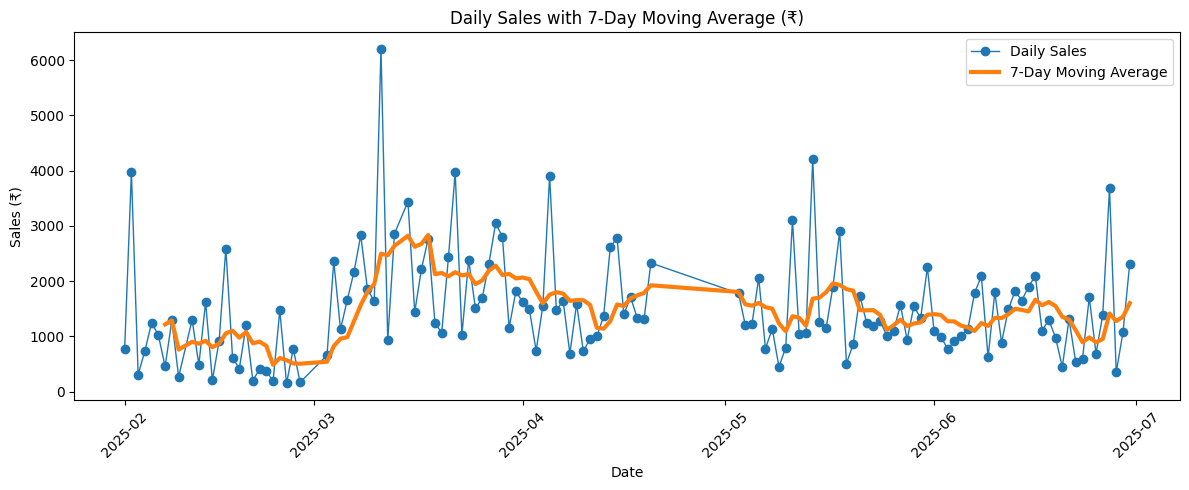

In [ ]:
import matplotlib.pyplot as plt
oper['Sales_MA7'] = oper['Sales'].rolling(7).mean()

plt.figure(figsize=(12,5))
plt.plot(oper['Date'], oper['Sales'], marker='o', linewidth=1, label='Daily Sales')
plt.plot(oper['Date'], oper['Sales_MA7'], linewidth=3, label='7-Day Moving Average')

plt.title("Daily Sales with 7-Day Moving Average (₹)")
plt.xlabel("Date")
plt.ylabel("Sales (₹)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


/tmp/ipykernel_5015/458187556.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_data = oper.groupby('Day')[['Sales','Net Profit']].mean().reindex(


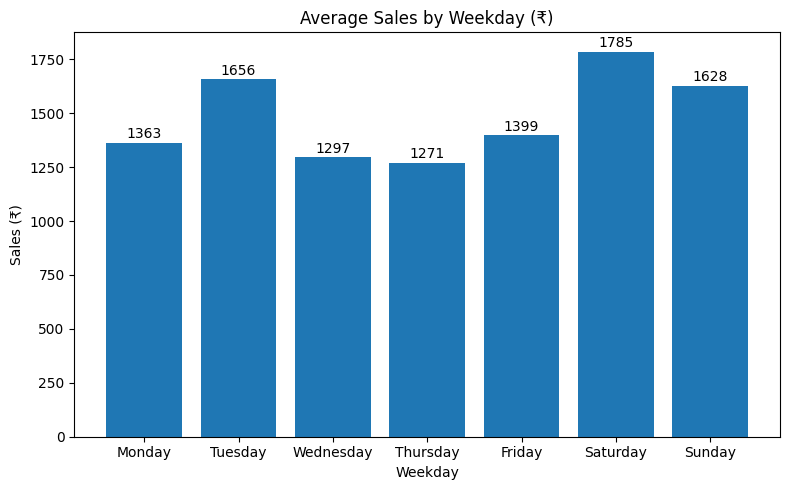

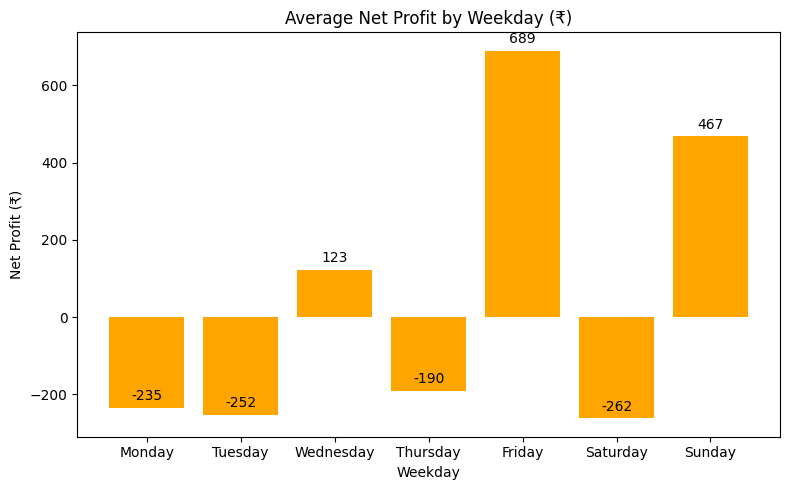

In [ ]:
import numpy as np

weekday_data = oper.groupby('Day')[['Sales','Net Profit']].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(8,5))
bars = plt.bar(weekday_data.index, weekday_data['Sales'])
plt.title("Average Sales by Weekday (₹)")
plt.xlabel("Weekday")
plt.ylabel("Sales (₹)")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval+20, f"{int(yval)}", ha='center')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
bars = plt.bar(weekday_data.index, weekday_data['Net Profit'], color='orange')
plt.title("Average Net Profit by Weekday (₹)")
plt.xlabel("Weekday")
plt.ylabel("Net Profit (₹)")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval+20, f"{int(yval)}", ha='center')

plt.tight_layout()
plt.show()


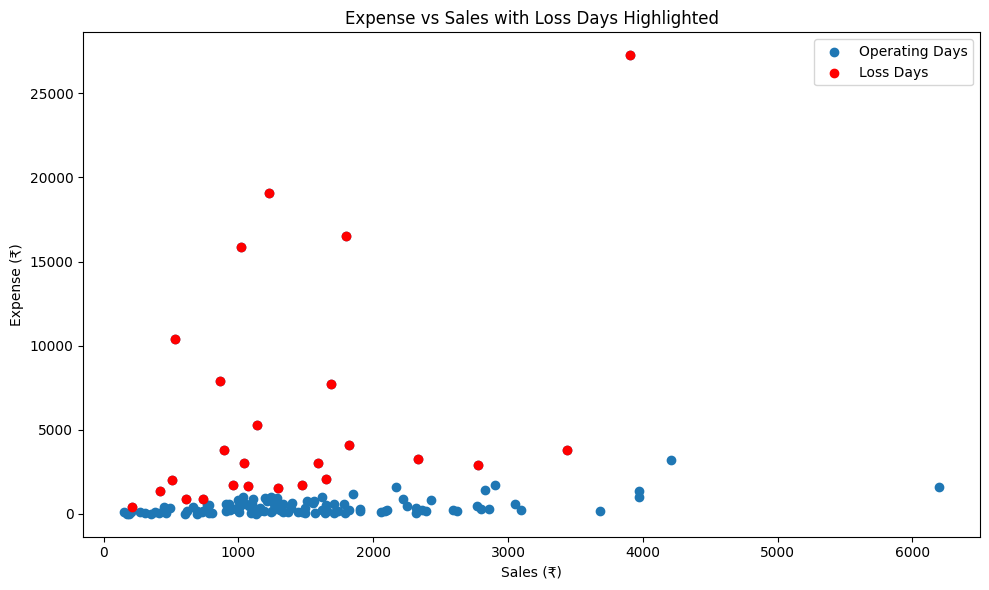

In [ ]:
loss_days = oper[oper['Net Profit'] < 0]

plt.figure(figsize=(10,6))
plt.scatter(oper['Sales'], oper['Expense'], label='Operating Days')
plt.scatter(loss_days['Sales'], loss_days['Expense'], color='red', label='Loss Days')

plt.title("Expense vs Sales with Loss Days Highlighted")
plt.xlabel("Sales (₹)")
plt.ylabel("Expense (₹)")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
print(loss_days['Expense'].mean())

5925.36


In [ ]:
print(oper['Expense'].mean())

1451.1353383458647


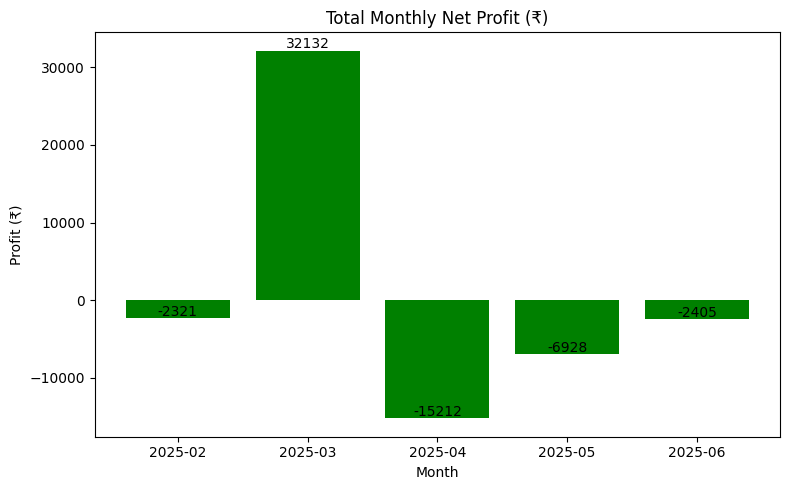

In [ ]:
oper['Month'] = oper['Date'].dt.to_period('M').astype(str)
month_profit = oper.groupby('Month')['Net Profit'].sum()

plt.figure(figsize=(8,5))
bars = plt.bar(month_profit.index, month_profit.values, color='green')

plt.title("Total Monthly Net Profit (₹)")
plt.xlabel("Month")
plt.ylabel("Profit (₹)")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval+300, f"{int(yval)}", ha='center')

plt.tight_layout()
plt.show()


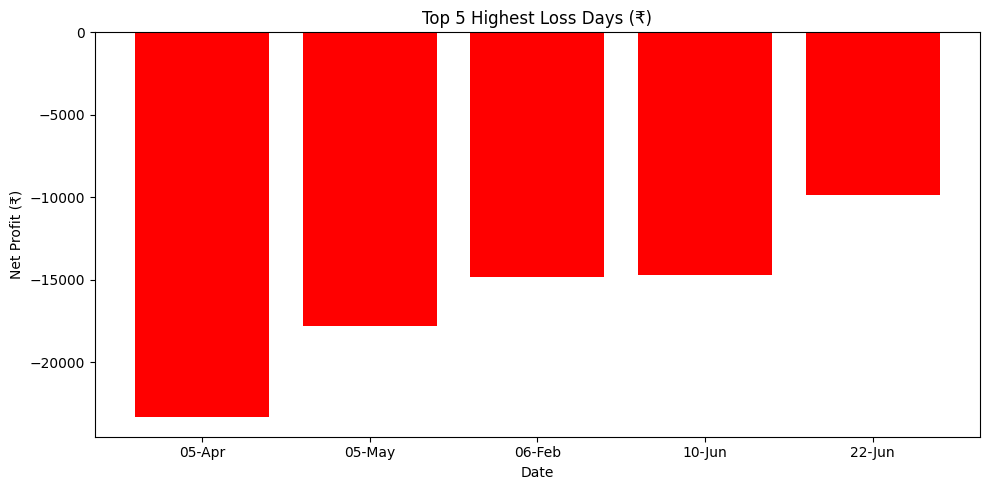

In [ ]:
top_losses = oper.nsmallest(5, 'Net Profit')

plt.figure(figsize=(10,5))
bars = plt.bar(top_losses['Date'].dt.strftime("%d-%b"), top_losses['Net Profit'], color='red')

plt.title("Top 5 Highest Loss Days (₹)")
plt.xlabel("Date")
plt.ylabel("Net Profit (₹)")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval-1000, f"{int(yval)}", ha='center', color='white')

plt.tight_layout()
plt.show()


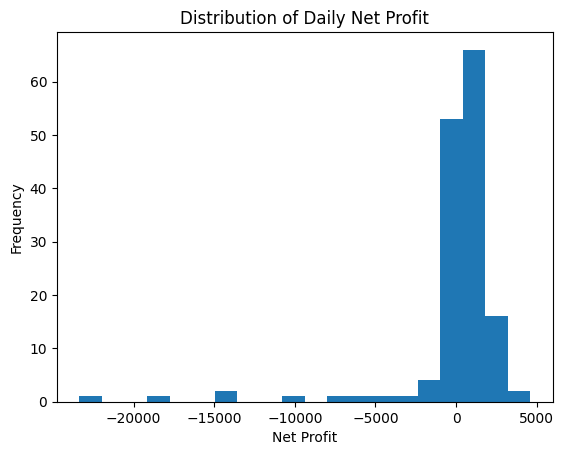

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Net Profit'].dropna(), bins=20)
plt.title('Distribution of Daily Net Profit')
plt.xlabel('Net Profit')
plt.ylabel('Frequency')
plt.show()

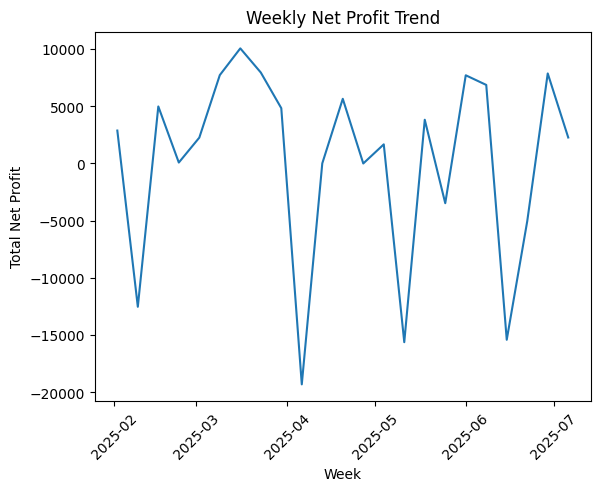

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

weekly_profit = df.resample('W', on='Date')['Net Profit'].sum()

plt.figure()
plt.plot(weekly_profit.index, weekly_profit.values)
plt.title('Weekly Net Profit Trend')
plt.xlabel('Week')
plt.ylabel('Total Net Profit')
plt.xticks(rotation=45)
plt.show()

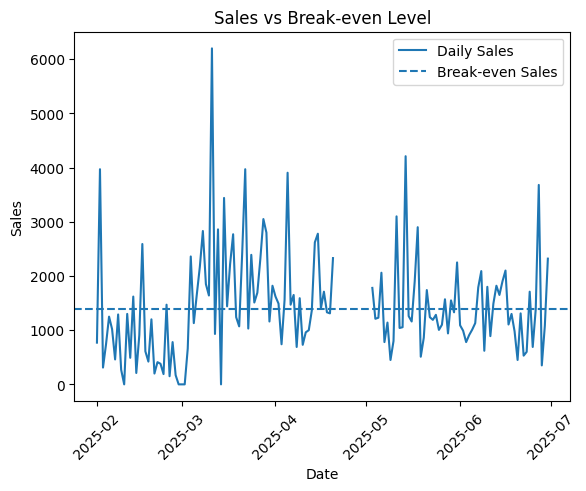

In [ ]:
break_even = df['Expense'].mean()

plt.figure()
plt.plot(df['Date'], df['Sales'], label='Daily Sales')
plt.axhline(y=break_even, linestyle='--', label='Break-even Sales')
plt.title('Sales vs Break-even Level')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()

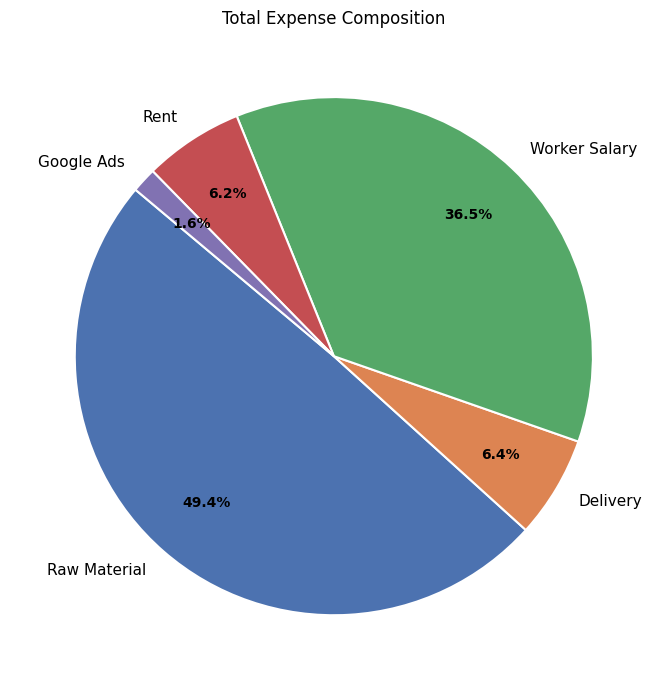

In [ ]:
cats = ['Raw material', 'Delivery Boy', 'Worker Salary', 'Rent', 'Google Ads']
labels = ['Raw Material', 'Delivery', 'Worker Salary', 'Rent', 'Google Ads']
totals = [oper[c].sum() for c in cats]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    totals,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

plt.title("Total Expense Composition")
plt.tight_layout()
plt.show()